# Exploratory Data Analysis (EDA) of Financial Data

**Project Overview**

This notebook presents a professional exploratory data analysis (EDA) of a financial dataset containing sales and cost information across different regions and products. The objective is to uncover key business insights, identify trends, and provide actionable recommendations for stakeholders. The analysis is designed for a portfolio, targeting recruiters and freelance clients, and demonstrates both technical and business acumen.

**Dataset Columns:**
- `date`: Transaction date
- `region`: Sales region
- `product`: Product name
- `revenue`: Sales revenue
- `cost`: Associated cost
- `units_sold`: Number of units sold

**Objectives:**
- Engineer new features (profit, margin)
- Analyze profitability by product and region
- Detect outliers and correlations
- Summarize actionable business insights

## 1. Import Libraries

In [6]:
# Import required libraries for data analysis and visualization
import pandas as pd      # Data manipulation and analysis
import numpy as np       # Numerical operations
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns    # Statistical data visualization

## 2. Configure Display and Plotting Options

In [15]:
# Set pandas display options for better readability
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Configure seaborn and matplotlib for professional plots
sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Load and Inspect Dataset

In [ ]:
# Load the financial dataset
# The file is expected at '../data/raw/financial_data.csv'
df = pd.read_csv("../data/raw/financial_data.csv")
df.head()
# Display the first few rows
display(df.head())

# Show dataset info
df.info()

,date,region,product,revenue,cost,units_sold
0,2022-01-01,North,Product A,12000,7000,300
1,2022-01-01,North,Product B,9500,5800,250
2,2022-01-01,North,Product C,13500,7600,320
3,2022-01-01,North,Product D,11000,6500,280
4,2022-01-01,North,Product E,14500,8200,340


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        480 non-null    datetime64[ns]
 1   region      480 non-null    object        
 2   product     480 non-null    object        
 3   revenue     480 non-null    int64         
 4   cost        480 non-null    int64         
 5   units_sold  480 non-null    int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 22.6+ KB


## 4. Feature Engineering: Profit and Margin

In [23]:
# Create new features: profit and margin
# Profit = revenue - cost (measures absolute earnings)
# Margin = profit / revenue (measures efficiency)
df['profit'] = df['revenue'] - df['cost']
df['margin'] = df['profit'] / df['revenue']

# Check the new features
display(df[['revenue', 'cost', 'profit', 'margin']].head())

,revenue,cost,profit,margin
0,12000,7000,5000,0.42
1,9500,5800,3700,0.39
2,13500,7600,5900,0.44
3,11000,6500,4500,0.41
4,14500,8200,6300,0.43


## 5. Descriptive Statistics

In [24]:
# Descriptive statistics for numerical features, including new ones
stats = df.describe().T
display(stats)

,count,mean,min,25%,50%,75%,max,std
date,480,2022-12-16 00:00:00,2022-01-01 00:00:00,2022-06-23 12:00:00,2022-12-16 12:00:00,2023-06-08 12:00:00,2023-12-01 00:00:00,NaN
revenue,480.00,"11,950.99","9,500.00","10,714.75","11,872.00","13,256.25","14,500.00","1,417.54"
cost,480.00,"7,075.55","5,800.00","6,436.75","7,106.00","7,690.00","8,200.00",700.78
units_sold,480.00,293.71,250.00,271.75,292.00,315.00,340.00,26.40
profit,480.00,"4,875.44","1,443.00","3,658.00","4,952.50","6,039.00","8,503.00","1,575.14"
margin,480.00,0.40,0.15,0.33,0.41,0.47,0.59,0.09


## 6. Profitability Analysis by Product

revenue    cost  profit          units_sold
               sum     sum     sum     mean        sum
product                                               
Product C  1150019  668967  481052 5,010.96      28090
Product D  1152411  675028  477383 4,972.74      28020
Product E  1155613  689312  466301 4,857.30      28419
Product A  1140690  678446  462244 4,815.04      28311
Product B  1137742  684512  453230 4,721.15      28143

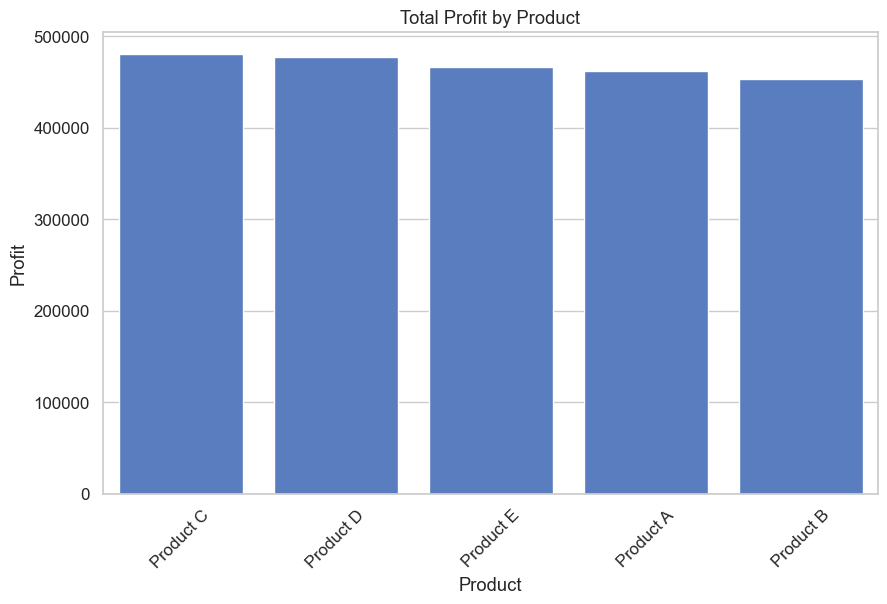

In [25]:
# Group by product and analyze profitability
product_profit = df.groupby('product').agg({
    'revenue': 'sum',
    'cost': 'sum',
    'profit': ['sum', 'mean'],
    'units_sold': 'sum'
}).sort_values(('profit', 'sum'), ascending=False)
display(product_profit)

# Visualize total profit by product
sns.barplot(x=product_profit.index, y=product_profit[('profit', 'sum')])
plt.title('Total Profit by Product')
plt.ylabel('Profit')
plt.xlabel('Product')
plt.xticks(rotation=45)
plt.show()

## 7. Regional Performance Analysis

,revenue,cost,profit,units_sold
region,,,,
North,1447826,851269,596557,35005
South,1428434,839065,589369,35595
East,1444095,857262,586833,35012
West,1416120,848669,567451,35371


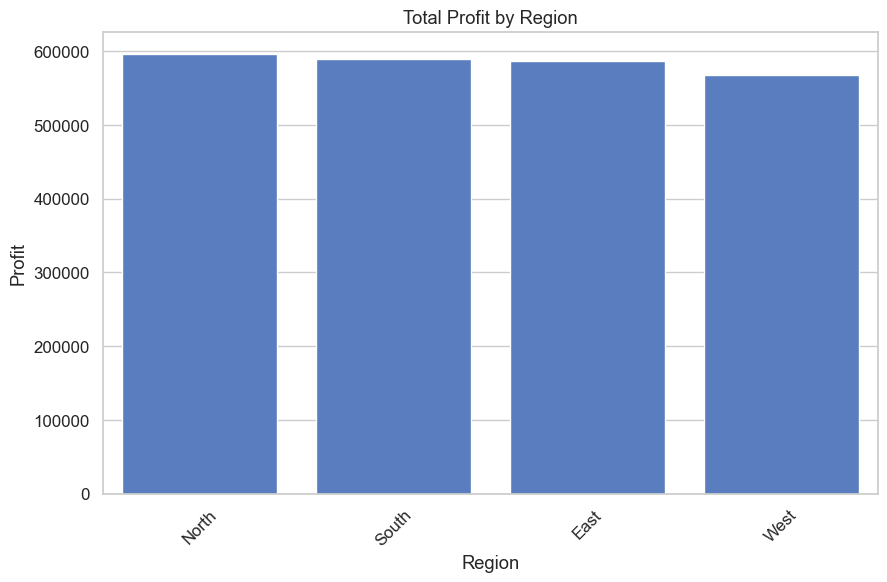

In [26]:
# Group by region and analyze performance
region_perf = df.groupby('region').agg({
    'revenue': 'sum',
    'cost': 'sum',
    'profit': 'sum',
    'units_sold': 'sum'
}).sort_values('profit', ascending=False)
display(region_perf)

# Visualize profit by region
sns.barplot(x=region_perf.index, y=region_perf['profit'])
plt.title('Total Profit by Region')
plt.ylabel('Profit')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.show()

## 8. Profit Outlier Detection

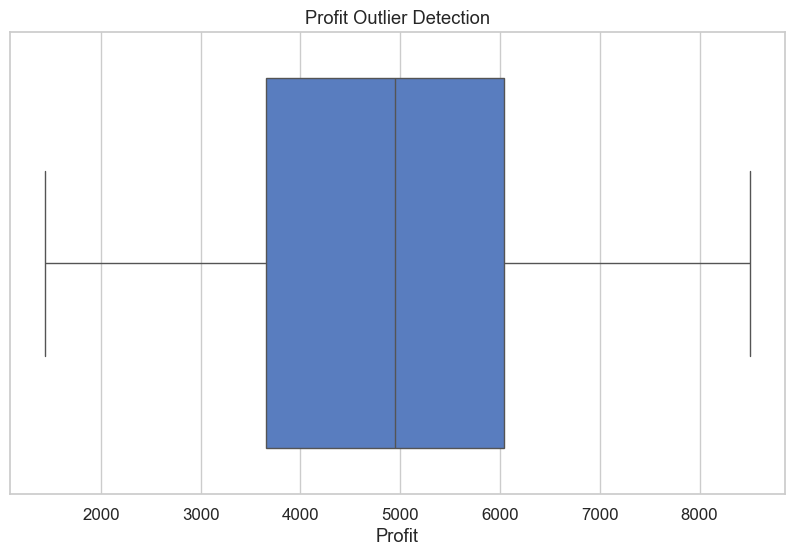

In [27]:
# Boxplot to detect outliers in profit
sns.boxplot(x=df['profit'])
plt.title('Profit Outlier Detection')
plt.xlabel('Profit')
plt.show()

## 9. Correlation Analysis

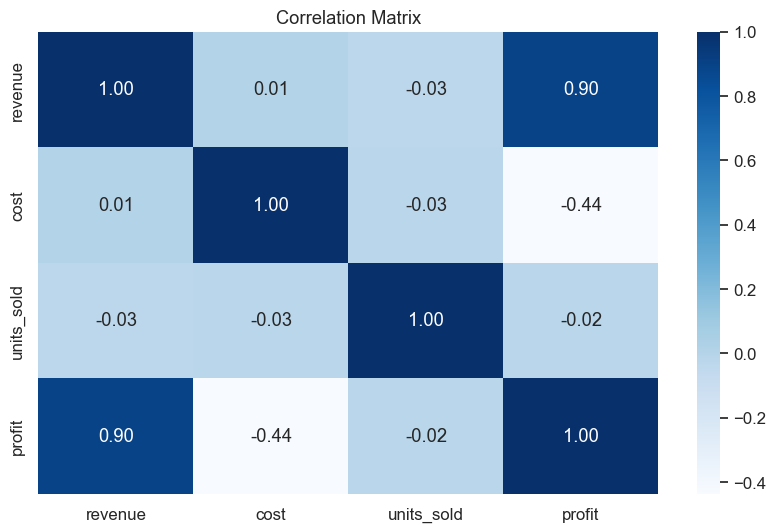

In [28]:
# Correlation matrix for key financial metrics
corr = df[['revenue', 'cost', 'units_sold', 'profit']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 10. Key Insights and Business Implications

- **Top-performing products and regions**: The analysis highlights which products and regions drive the most profit, guiding resource allocation and strategic focus.
- **Profitability drivers**: Feature engineering and correlation analysis reveal the main factors influencing profitability.
- **Outlier detection**: Identifying outliers in profit can help investigate anomalies and improve data quality or business processes.

**Business Implications:**

- Focus on high-margin products and regions to maximize returns.
- Investigate underperforming segments for improvement opportunities.
- Use insights to inform pricing, marketing, and operational decisions.

---

*This notebook demonstrates a structured, business-oriented approach to financial data analysis, suitable for professional portfolios and client presentations.*